In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, RobustScaler, StandardScaler, FunctionTransformer

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.cluster import KMeans
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity


import warnings
warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
device

device(type='cpu')

In [3]:
df=pd.read_csv("final_database.csv")

In [4]:
def fill_missing_values(df):
    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(0).astype(int)
        elif df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
    return df

df = fill_missing_values(df)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5546 entries, 0 to 5545
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   catcher_id                     5546 non-null   int64 
 1   jobma_catcher_status           5546 non-null   int64 
 2   jobma_catcher_type             5546 non-null   int64 
 3   is_premium                     5546 non-null   int64 
 4   subscription_status            5546 non-null   int64 
 5   sub_user                       5546 non-null   int64 
 6   per_sub_user                   5546 non-null   object
 7   subscription_type_x            5546 non-null   int64 
 8   referral_credit                5546 non-null   int64 
 9   company_size                   5546 non-null   object
 10  ai_live_interview              5546 non-null   int64 
 11  days_since_creation            5546 non-null   int64 
 12  number_of_logins               5546 non-null   int64 
 13  day

In [6]:
binary_columns = ['jobma_catcher_status',
                  'jobma_catcher_type',
                  'is_premium',
                  'subscription_type_x',
                  'referral_credit',
                  'ai_live_interview',
                  'subscription_type_y',
                  'plan_type',
                  'is_unlimited',
                  'currency'
                 ]

categorical_columns = ['subscription_status',
                       'per_sub_user',
                       'company_size',
                      ]
                   
ordinal_columns = ['sub_user',#
                   'days_since_creation',#
                   'number_of_logins',#
                   'days_since_login',#
                   'wallet_sum',#
                   'subscription_sum',#
                   'subscription_count',#
                   'ai_kit_counts',#
                   'pre_recorded_kit_counts',#
                   'number_of_jobs_posted',#
                   'number_of_pitcher_invitations',#
                   'number_of_pitchers_applied',#
                   'pre_rec_interviews_counts',#
                   'live_interviews_counts',#
                   'ai_interviews_counts',#done
                   ]

In [7]:
# Clean binary values , # Remove negatives and  clamp to 0
def clean_binary(X):
    return X.apply(lambda col: col.map(lambda val: 1 if pd.to_numeric(val, errors='coerce') > 0 else 0))
    
def clean_categorical(X):
    return X.apply(lambda col: col.map(lambda val: str(val).strip().lower() if pd.notnull(val) else 'others'))

def clean_ordinal(X):
    return X.clip(lower=0)

In [8]:
#pipeline 
binary_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_binary, validate=False)),
                                  ('imputer', SimpleImputer(strategy='most_frequent')),
                                  ('Scaler', StandardScaler())
                                 ])

categorical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_categorical, validate=False)),
                                       ('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                                      ])

ordinal_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_ordinal, validate=False)),
                                   ('imputer', SimpleImputer(strategy='median')),
                                   ('scaler', MinMaxScaler())
                                  ])

# Combined preprocessor
preprocessor = ColumnTransformer(transformers=[('bin', binary_pipeline, binary_columns),
                                               ('cat', categorical_pipeline, categorical_columns),
                                               ('ord', ordinal_pipeline, ordinal_columns)
                                              ])

pipeline = Pipeline([('preprocessing', preprocessor)])

In [9]:
preprocessor

ColumnTransformer(transformers=[('bin',
                                 Pipeline(steps=[('cleaner',
                                                  FunctionTransformer(func=<function clean_binary at 0x000002668FE03EB0>)),
                                                 ('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('Scaler', StandardScaler())]),
                                 ['jobma_catcher_status', 'jobma_catcher_type',
                                  'is_premium', 'subscription_type_x',
                                  'referral_credit', 'ai_live_interview',
                                  'subscription_...
                                                 ('scaler', MinMaxScaler())]),
                                 ['sub_user', 'days_since_creation',
                                  'number_of_logins', 'days_since_login',
                                  'wallet_sum', 'subscription_sum',
                                  'subscription_count', 'ai_kit_counts',
                                  'pre_recorded_kit_counts',
                                  'number_of_jobs_posted',
                                  'number_of_pitcher_invitations',
                                  'number_of_pitchers_applied',
                                  'pre_rec_interviews_counts',
                                  'live_interviews_counts',
                                  'ai_interviews_counts'])])

In [10]:
X = df.copy()

In [11]:
X_scaled = pipeline.fit_transform(X)

In [12]:
class CustomDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [13]:
batch_size = 16
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
dataset = CustomDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [14]:
len(X_scaled), len(X_tensor), len(dataset), len(dataloader), batch_size, X_scaled.shape

(5546, 5546, 5546, 347, 16, (5546, 42))

In [15]:
# Autoencoder for robustness
class AutoEncoder(nn.Module):
    def __init__(self, input_shape):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_shape, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_shape)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

In [16]:
X_scaled.shape[1], X_tensor.shape[1]

(42, 42)

In [17]:
input_dim = X_tensor.shape[1]
model = AutoEncoder(input_dim)
model.to(device)

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=42, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=42, bias=True)
  )
)

In [18]:
input_dim

42

# Optimizer and scheduler and other loss function

In [19]:
# Loss functions
mse_loss_function = nn.SmoothL1Loss()
cosine_loss_function = nn.CosineEmbeddingLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5)

# Training Model

In [20]:
torch.manual_seed(42)
epochs = 10
model.train()

for epoch in range(epochs):
    epoch_total_loss = 0
    for batch_X in dataloader:
        batch_X = batch_X.to(device)

        # Forward pass
        encoded, decoded = model(batch_X)
        mse_loss = mse_loss_function(decoded, batch_X)

        # Cosine Embedding Loss
        batch_size = encoded.size(0)
        target_labels = torch.ones(batch_size, device=device)

        # Shuffling the encoded vectors 
        permuted_indices = torch.randperm(batch_size, device=device)
        encoded_shuffled = encoded[permuted_indices]

        # Calculating Cosine Embedding Loss
        cosine_loss = cosine_loss_function(encoded, encoded_shuffled, target_labels)

        # Total Loss =constrtion +cosine
        total_loss = mse_loss + cosine_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        epoch_total_loss += total_loss.item()

    # Average loss over all batches in the epoch
    training_loss = epoch_total_loss / len(dataloader)
    print(f'Epoch {epoch+1}/{epochs} | Training Loss: {training_loss:.5f}')
    scheduler.step(training_loss)

Epoch 1/10 | Training Loss: 0.06968
Epoch 2/10 | Training Loss: 0.04868
Epoch 3/10 | Training Loss: 0.04389
Epoch 4/10 | Training Loss: 0.03843
Epoch 5/10 | Training Loss: 0.03590
Epoch 6/10 | Training Loss: 0.03347
Epoch 7/10 | Training Loss: 0.03132
Epoch 8/10 | Training Loss: 0.02921
Epoch 9/10 | Training Loss: 0.02694
Epoch 10/10 | Training Loss: 0.02399


In [21]:
model.eval()
with torch.no_grad():
    encoder, _ = model(X_tensor)
latent_np = encoder.cpu().numpy()

In [22]:
wcss = []
silhouette_scores = []
k_range = range(2,11)
torch.manual_seed(42)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(latent_np)
    wcss.append(kmeans.inertia_)  # Inertia = WCSS
    silhouette_scores.append(silhouette_score(latent_np, labels))

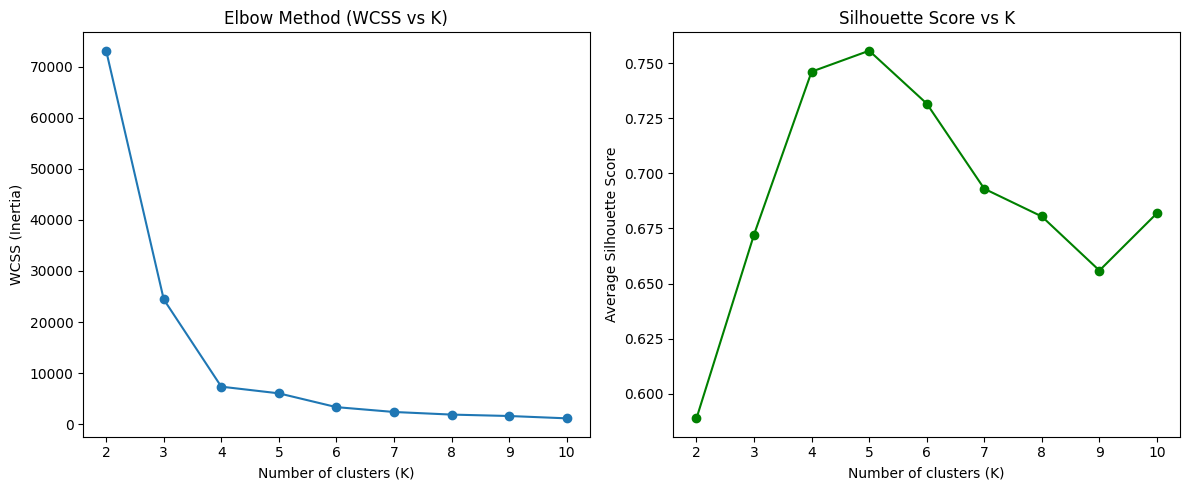

In [23]:
#Elbow Rule to decide the number of clusters with silhoute score
torch.manual_seed(42)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o')
plt.title('Elbow Method (WCSS vs K)')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS (Inertia)')

# Step 5: Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score vs K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Average Silhouette Score')

plt.tight_layout()
plt.show()

In [35]:
#Initialising KMeans
kmeans = KMeans(n_clusters=4, n_init=input_dim)
cluster_ids = kmeans.fit_predict(latent_np)
cluster_centers = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32).to(device)

In [36]:
# Deep Embedding Clusturing Model
class DEC(nn.Module):
    def __init__(self, encoder, cluster_centers):
        super(DEC, self).__init__()
        self.encoder = encoder
        self.cluster_centers = nn.Parameter(cluster_centers)

    def forward(self, x):
        z = self.encoder(x)
        q = 1.0 / (1.0 + torch.sum((z.unsqueeze(1) - self.cluster_centers)**2, dim=2))
        q = q.pow((1 + 1) / 2.0)
        q = (q.t() / torch.sum(q, dim=1)).t()
        return q, z

def target_distribution(q):
    weight = q**2 / q.sum(0)
    return (weight.t() / weight.sum(1)).t()  

In [37]:
dec = DEC(model.encoder, cluster_centers.clone()).to(device)

In [38]:
kl_loss = nn.KLDivLoss(reduction='batchmean')
optimizer = torch.optim.Adam(dec.parameters(), lr=1e-4)

In [39]:
torch.manual_seed(42)
dec.train()
num_epochs = 20
for epoch in range(num_epochs):
    for batch in dataloader:
        x = batch.to(device)
        q, z = dec(x)
        p = target_distribution(q)

        # Compute loss
        loss = kl_loss(q.log(), p)
        
        # Backpropogation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}")

Epoch 1/20, Loss: 0.0383
Epoch 2/20, Loss: 0.0115
Epoch 3/20, Loss: 0.0305
Epoch 4/20, Loss: 0.0110
Epoch 5/20, Loss: 0.0114
Epoch 6/20, Loss: 0.0180
Epoch 7/20, Loss: 0.0103
Epoch 8/20, Loss: 0.0286
Epoch 9/20, Loss: 0.0100
Epoch 10/20, Loss: 0.0096
Epoch 11/20, Loss: 0.0095
Epoch 12/20, Loss: 0.0093
Epoch 13/20, Loss: 0.0090
Epoch 14/20, Loss: 0.0082
Epoch 15/20, Loss: 0.0136
Epoch 16/20, Loss: 0.0083
Epoch 17/20, Loss: 0.0122
Epoch 18/20, Loss: 0.0089
Epoch 19/20, Loss: 0.0134
Epoch 20/20, Loss: 0.0195


In [29]:
# 2d plotting

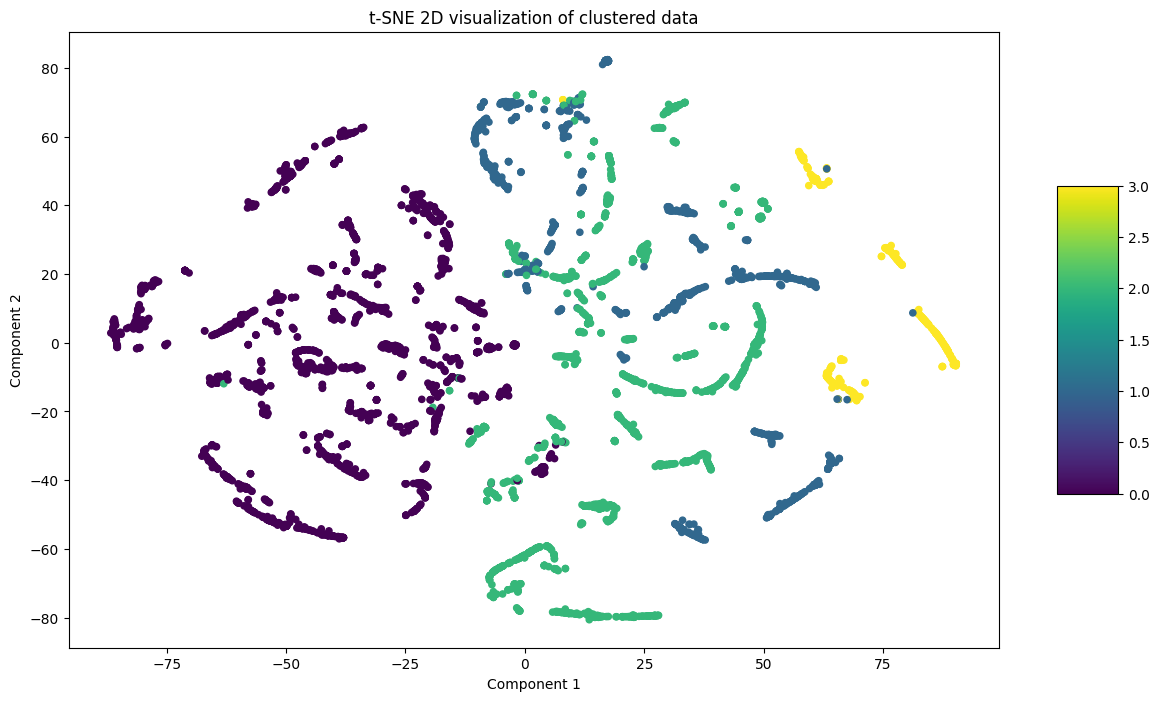

In [40]:
with torch.no_grad():
    _, z = dec(X_tensor.to(device))
    z_2d = TSNE(n_components=2, random_state=42).fit_transform(z.cpu().numpy())
fig, ax = plt.subplots(figsize=(15, 8))
scatter = ax.scatter(z_2d[:, 0], z_2d[:, 1], c=cluster_ids, cmap='viridis', s=20)
ax.set_title('t-SNE 2D visualization of clustered data')
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
plt.colorbar(scatter, ax=ax, shrink=0.5, aspect=5)
plt.show()

In [31]:
#3d representation

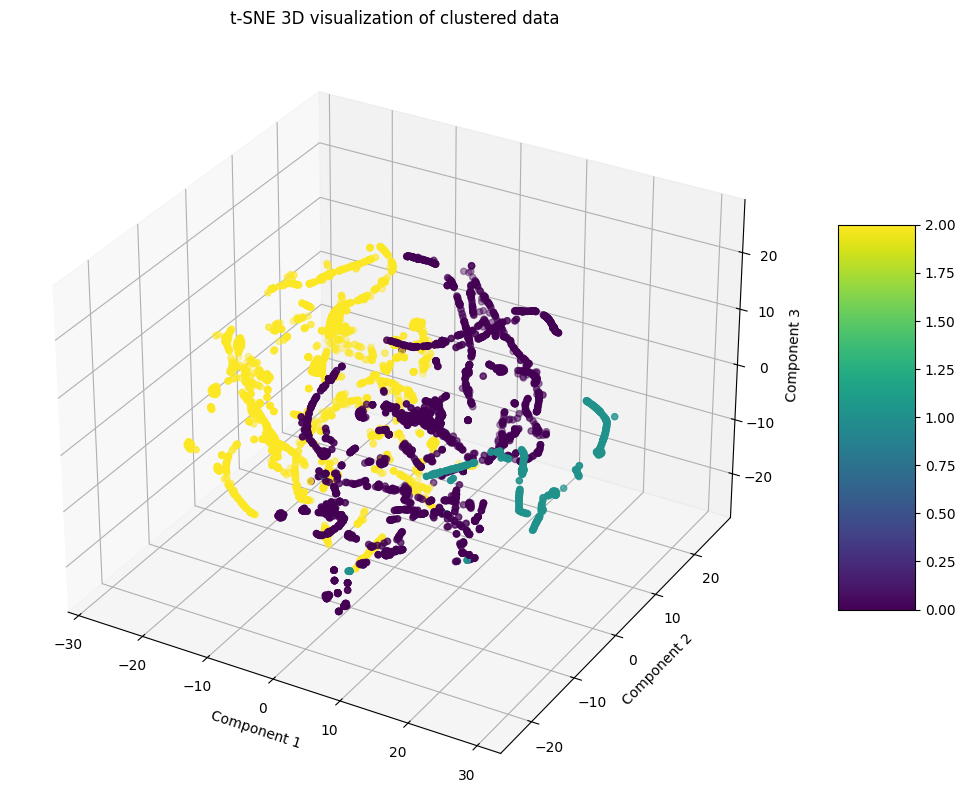

In [32]:
from mpl_toolkits.mplot3d import Axes3D

dec.eval()
with torch.no_grad():
    _, z = dec(X_tensor.to(device))
    z_3d = TSNE(n_components=3, random_state=42).fit_transform(z.cpu().numpy())

    fig = plt.figure(figsize=(15, 10))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(z_3d[:, 0], z_3d[:, 1], z_3d[:, 2], c=cluster_ids, cmap='viridis', s=20)
    
    ax.set_title('t-SNE 3D visualization of clustered data')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_zlabel('Component 3')
    plt.colorbar(scatter, ax=ax, shrink=0.5, aspect=5)
    plt.show()

In [33]:
import numpy as np
from collections import Counter

cluster_ids_np = np.array(cluster_ids)
cluster_counts = Counter(cluster_ids_np)
for i, (cluster_id, count) in enumerate(sorted(cluster_counts.items())):
    print(f"Cluster {i + 1} (ID: {cluster_id}): {count} points")

Cluster 1 (ID: 0): 2690 points
Cluster 2 (ID: 1): 407 points
Cluster 3 (ID: 2): 2449 points


In [41]:
sample_data = pd.DataFrame({
    'JObma_catcher_id':[1873]
    'jobma_catcher_status': [1],
    'jobma_catcher_type': [1],
    'is_premium': [1],
    'subscription_type_x': [1],
    'referral_credit': [0],
    'ai_live_interview': [1],
    'subscription_type_y': [1],
    'plan_type': [0],
    'is_unlimited': [1],
    'currency': [1],
    'subscription_status': ['active'],
    'per_sub_user': [100],
    'company_size': ['500-1000'],
    'sub_user': [105],
    'days_since_creation': [120],
    'number_of_logins': [40],
    'days_since_login': [5],
    'wallet_sum': [200],
    'subscription_sum': [500],
    'subscription_count': [238],
    'ai_kit_counts': [32],
    'pre_recorded_kit_counts': [297],
    'number_of_jobs_posted': [547],
    'number_of_pitcher_invitations': [2000],
    'number_of_pitchers_applied': [728],
    'pre_rec_interviews_counts': [604],
    'live_interviews_counts': [113],
    'ai_interviews_counts': [67],
})


sample_scaled = pipeline.transform(sample_data)
sample_tensor = torch.tensor(sample_scaled, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    sample_embedding, _ = model(sample_tensor)

# `encoder` is the latent representation of full dataset from training
cos_sim = cosine_similarity(sample_embedding.cpu().numpy(), encoder.cpu().numpy())
top_k_idx = np.argsort(cos_sim[0])[::-1][:5]


SyntaxError: invalid syntax. Perhaps you forgot a comma? (3660022141.py, line 2)

In [42]:
recommended_clients = df.iloc[top_k_idx]
recommended_clients

NameError: name 'top_k_idx' is not defined